In [1]:
import torch
from base_model import *
from utils import *
from custom_layer import *

In [2]:
torch.backends.mkldnn.enabled = True

In [3]:
train_dataset, val_dataset = get_dataset()
criterion = torch.nn.CrossEntropyLoss()

In [4]:
block0 = nn.Sequential(
    nn.BatchNorm2d(3),#Not normal to use batchnorm at the beginning of the network, but based on empirical results, it can improve the performance of small model
    nn.Conv2d(3, 30, 3, padding=1, groups=3),
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),

    nn.Conv2d(30, 30, 3, padding=1, groups=30),
    nn.BatchNorm2d(30),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 32 → 16

    nn.Conv2d(30, 30, 1),   # pointwise conv
    nn.BatchNorm2d(30),
    nn.PReLU(),
)
block1 = nn.Sequential(
    # -------- Block 2 --------
    nn.Conv2d(30, 60, 3, padding=1,groups=30),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1,groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 16 → 8

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block2 = nn.Sequential(
    # -------- Block 3 --------
    nn.Conv2d(60, 120, 3, padding=1, groups=60),
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 120, 1),   # pointwise conv
    nn.BatchNorm2d(120),
    nn.PReLU(),

    nn.Conv2d(120, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 8 → 4

    nn.Conv2d(60, 60, 1),   # pointwise conv
    nn.BatchNorm2d(60),
    nn.PReLU(),
)
block3 = nn.Sequential(
    # -------- Block 4 --------
    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),

    nn.Conv2d(60, 60, 3, padding=1, groups=60),
    nn.BatchNorm2d(60),
    nn.PReLU(),
    nn.MaxPool2d(2),          # 4 → 2

    # nn.Conv2d(60, 60, 1),   # pointwise conv
    # nn.BatchNorm2d(60),
    # nn.PReLU(),
)

classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(240, 10)
)

In [5]:
model33_0 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model33_0)
describe(model33_0)

MACs: 5.24 MMac, Params: 36.81 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model33_0.pt
Starting
Epoch 1/60: Train loss = 1.0874, Train accuracy = 0.6095, Test loss = 1.0285, Test accuracy = 0.6345
Epoch 2/60: Train loss = 0.9470, Train accuracy = 0.6651, Test loss = 0.9351, Test accuracy = 0.6738
Epoch 3/60: Train loss = 0.8330, Train accuracy = 0.7082, Test loss = 0.8318, Test accuracy = 0.7118
Epoch 4/60: Train loss = 0.7803, Train accuracy = 0.7258, Test loss = 0.8034, Test accuracy = 0.7254
Epoch 5/60: Train loss = 0.6701, Train accuracy = 0.7665, Test loss = 0.6824, Test accuracy = 0.7634
Epoch 6/60: Train loss = 0.6528, Train accuracy = 0.7725, Test loss = 0.6672, Test accuracy = 0.7734
Epoch 7/60: Train loss = 0.6186, Train accuracy = 0.7866, Test loss = 0.6318, Test accuracy = 0.7893
Epoch 8/60: Train loss = 0.5963, Train accuracy = 0.7926, Test loss = 0.6266, Test accuracy = 0.7869
Epoch 9/60: Train loss = 0.5584, Train accuracy = 0.8061, Test loss = 0.6015, Test accuracy = 0.7991
Epoch 10/60: Train loss = 0.581

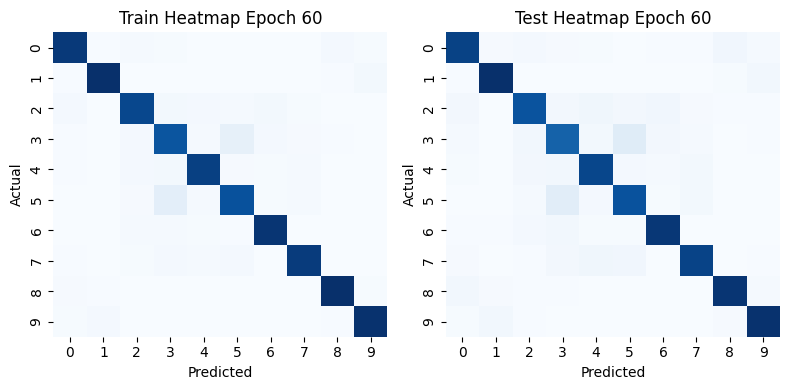

<Figure size 1200x600 with 0 Axes>

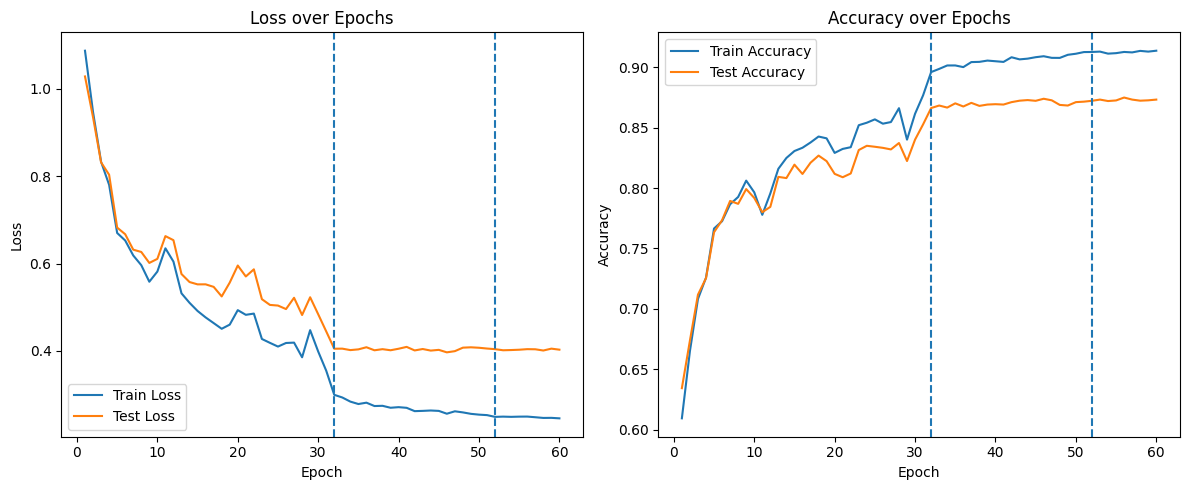

In [6]:
trainf32(model33_0,"model_weights/model33_0.pt",criterion,train_dataset,val_dataset, batch_size=128)

In [7]:
model33_1 = BaseModelF32([block0, block1, block2, block3], classifier)
he_initialization(model33_1)
describe(model33_1)

MACs: 5.24 MMac, Params: 36.81 k
Layer (type:depth-idx)                   Output Shape              Param #
BaseModelF32                             [1, 10]                   --
├─ModuleList: 1-1                        --                        --
│    └─Sequential: 2-1                   [1, 30, 16, 16]           --
│    │    └─BatchNorm2d: 3-1             [1, 3, 32, 32]            6
│    │    └─Conv2d: 3-2                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-3             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-4                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-5                  [1, 30, 32, 32]           930
│    │    └─BatchNorm2d: 3-6             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-7                   [1, 30, 32, 32]           1
│    │    └─Conv2d: 3-8                  [1, 30, 32, 32]           300
│    │    └─BatchNorm2d: 3-9             [1, 30, 32, 32]           60
│    │    └─PReLU: 3-10                  [1, 30, 32,

Loading checkpoint from model_weights/model33_1.pt
Starting
Epoch 1/60: Train loss = 1.1142, Train accuracy = 0.6144, Test loss = 1.0689, Test accuracy = 0.6321
Epoch 2/60: Train loss = 0.9076, Train accuracy = 0.6867, Test loss = 0.9021, Test accuracy = 0.6941
Epoch 3/60: Train loss = 0.8654, Train accuracy = 0.6967, Test loss = 0.8638, Test accuracy = 0.7008
Epoch 4/60: Train loss = 0.7047, Train accuracy = 0.7558, Test loss = 0.7066, Test accuracy = 0.7572
Epoch 5/60: Train loss = 0.6675, Train accuracy = 0.7675, Test loss = 0.6805, Test accuracy = 0.7715
Epoch 6/60: Train loss = 0.6474, Train accuracy = 0.7764, Test loss = 0.6865, Test accuracy = 0.7716
Epoch 7/60: Train loss = 0.5757, Train accuracy = 0.7992, Test loss = 0.5861, Test accuracy = 0.7998
Epoch 8/60: Train loss = 0.6036, Train accuracy = 0.7875, Test loss = 0.6204, Test accuracy = 0.7872
Epoch 9/60: Train loss = 0.5208, Train accuracy = 0.8179, Test loss = 0.5699, Test accuracy = 0.8034
Epoch 10/60: Train loss = 0.521

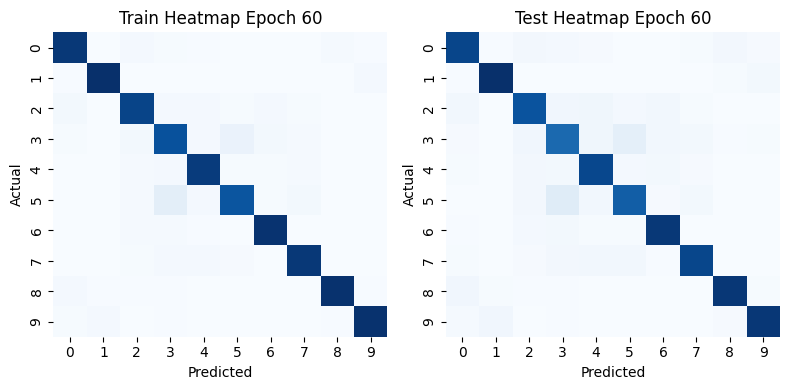

<Figure size 1200x600 with 0 Axes>

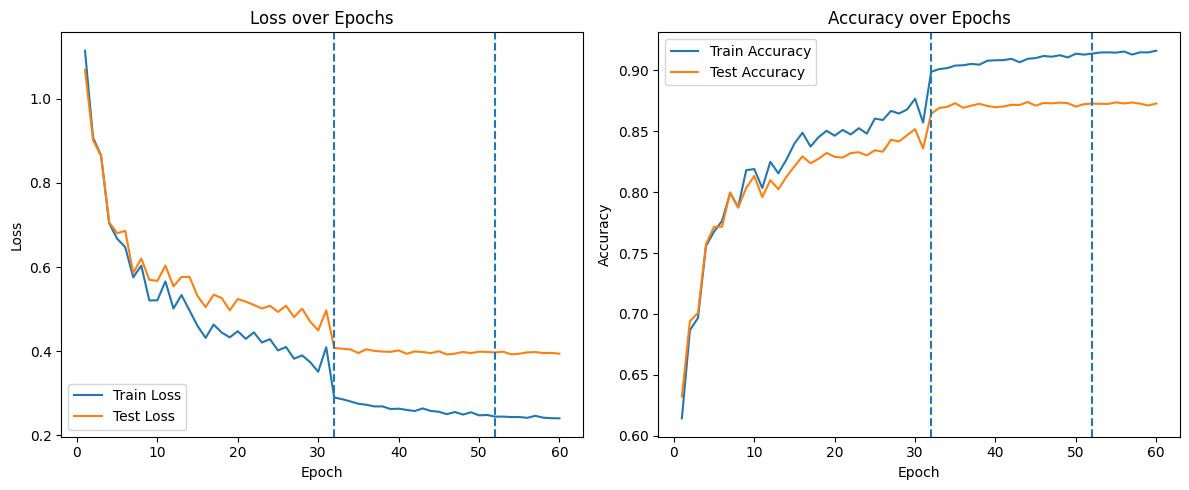

In [8]:
trainf32(model33_1,"model_weights/model33_1.pt",criterion,train_dataset,val_dataset, batch_size=64)